# Example 5 — Derating with a HAWCStab2 surrogate (DTU 10MW)

Derating (downregulation) reduces a turbine's power *and thrust*, so its wake
carries a smaller deficit — upstream derating can pay for itself through
downstream recovery. This notebook shows the **surrogate-based** approach:
the turbine's power and ct are tabulated over (wind speed, yaw, derating) by
HAWCStab2, where for every operating point the pitch/TSR combination is chosen
to meet the power target with **minimum ct**. The table is wrapped in a PyWake
`PowerCtNDTabular`, so the turbine accepts `derate` (and `yaw`) natively —
WindGym only forwards per-turbine derate values.

**Surrogate file**: a reduced copy (power + ct only, float32, ~4.6 MB) ships
with WindGym at `examples/data/dtu10mw_derating_yaw_surrogate.nc`. The full
table (incl. tsr/pitch/cp) was generated with
[hawcpowerctcurvegenerator](https://gitlab.windenergy.dtu.dk/TOPFARM/cuttingedge/pywake/hawcpowerctcurvegenerator)
(see its Tutorial notebook) — regenerate it there if you need the extra
variables or a different turbine.

The surrogate's yaw dimension **replaces** PyWake's default cos³
`SimpleYawModel`, so yaw losses follow the HAWC2 aerodynamics, including the
yaw-derating interaction.

Contents:
1. Build the surrogate turbine
2. The surrogate table
3. Power and ct vs derating
4. Yaw x derating interaction
5. Three side-by-side turbines — power / ct bars
6. Flow map — wakes shrink with derating
7. Waked row — the control tradeoff
8. Derating inside WindGym (RL setting)
9. Rendered flow — two front turbines derated (gif)
10. 3 x 1 farm — phase-offset pulsating derating (gif)

In [ ]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

from py_wake.literature.gaussian_models import Blondel_Cathelain_2020
from py_wake.turbulence_models import STF2017TurbulenceModel
from py_wake.deflection_models.jimenez import JimenezWakeDeflection
from py_wake.site import UniformSite
from py_wake import HorizontalGrid

# Reduced surrogate (power + ct only, float32) shipped with WindGym.
# See the intro for how to regenerate the full table with hawcpowerctcurvegenerator.
SURROGATE_NC = Path("data/dtu10mw_derating_yaw_surrogate.nc")
assert SURROGATE_NC.exists(), (
    f"surrogate not found: {SURROGATE_NC.resolve()} — run this notebook from the "
    "examples/ directory, or regenerate the table with hawcpowerctcurvegenerator "
    "(see the intro above)."
)

## 1. Build the surrogate turbine

`PowerCtNDTabular` takes the (ws, yaw, derate) grids plus power/ct arrays.
Two details matter:

- `default_value_dict={'yaw': 0, 'derate': 0}` makes `yaw`/`derate` *optional*
  inputs, so plain `turbine.power(ws)` calls keep working.
- `SimpleYawModel` is **not** in `additional_models` — the surrogate's own yaw
  dimension handles misalignment (keeping both would double-count yaw losses).
- interpolator bounds are set to `'limit'` so out-of-table queries
  (|yaw| > 40°, derate > 0.8, ws > 25 m/s) clamp to the edge instead of raising.

In [2]:
from py_wake.examples.data.dtu10mw._dtu10mw import DTU10MW
from py_wake.wind_turbines import WindTurbine
from py_wake.wind_turbines.power_ct_functions import DensityScale, PowerCtNDTabular


def make_derating_dtu10mw(nc_path=SURROGATE_NC) -> WindTurbine:
    ds = xr.load_dataset(nc_path).transpose("ws", "yaw", "derating")
    ref = DTU10MW()

    pctf = PowerCtNDTabular(
        input_keys=["ws", "yaw", "derate"],
        value_lst=[ds.ws.values, ds.yaw.values.astype(float), ds.derating.values],
        power_arr=ds.power.values,
        power_unit="W",
        ct_arr=ds.ct.values,
        default_value_dict={"yaw": 0.0, "derate": 0.0},
        additional_models=[DensityScale(1.225)],
    )
    for gi in pctf.interp:
        gi.bounds = "limit"

    return WindTurbine(
        name="DTU10MW",
        diameter=ref.diameter(),
        hub_height=ref.hub_height(),
        powerCtFunction=pctf,
    )


wt = make_derating_dtu10mw()
print("optional_inputs:", wt.powerCtFunction.optional_inputs)
print(f"D = {wt.diameter():.1f} m, hub height = {wt.hub_height():.1f} m")

optional_inputs: ['Air_density', 'derate', 'yaw']
D = 178.3 m, hub height = 119.0 m


## 2. The surrogate table

Power and ct as functions of wind speed and derating level (yaw = 0 slice).
`derating` is the fraction of available power removed:
power = (1 - derating) * P_available. The table covers derating 0-0.8 and
yaw ±40°.

<xarray.Dataset> Size: 66MB
Dimensions:   (ws: 251, yaw: 81, derating: 81)
Coordinates:
  * ws        (ws) float64 2kB 0.0 0.1 0.2 0.3 0.4 ... 24.6 24.7 24.8 24.9 25.0
  * yaw       (yaw) int32 324B -40 -39 -38 -37 -36 -35 -34 ... 35 36 37 38 39 40
  * derating  (derating) float64 648B 0.0 0.01 0.02 0.03 ... 0.77 0.78 0.79 0.8
Data variables:
    tsr       (ws, yaw, derating) float64 13MB ...
    pitch     (ws, yaw, derating) float64 13MB ...
    cp        (ws, yaw, derating) float64 13MB ...
    power     (ws, yaw, derating) float64 13MB ...
    ct        (ws, yaw, derating) float64 13MB ...


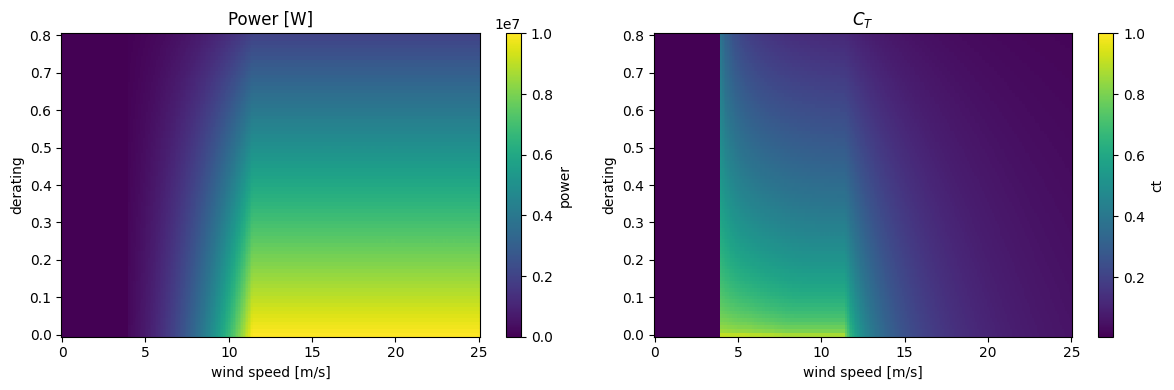

In [3]:
ds = xr.open_dataset(SURROGATE_NC)
print(ds)

sel = ds.sel(yaw=0)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sel.power.T.plot(ax=axes[0], cmap="viridis")
axes[0].set_title("Power [W]")
sel.ct.T.plot(ax=axes[1], cmap="viridis", vmax=1.0)
axes[1].set_title("$C_T$")
for ax in axes:
    ax.set_xlabel("wind speed [m/s]"); ax.set_ylabel("derating")
plt.tight_layout()

## 3. Power and ct vs derating

At a fixed 9 m/s inflow, sweep the derating level. By construction the power
fraction is exactly `1 - derate`. The interesting part is **ct**: the min-ct
re-optimisation sheds thrust much faster than power — already at 10% derating,
ct drops from ~0.87 to ~0.63. Less thrust means a weaker wake, which is the
whole point of derating as a wake-control action.

P/P0: [1.  0.8 0.6 0.4 0.2]
Ct  : [0.871 0.519 0.364 0.24  0.131]


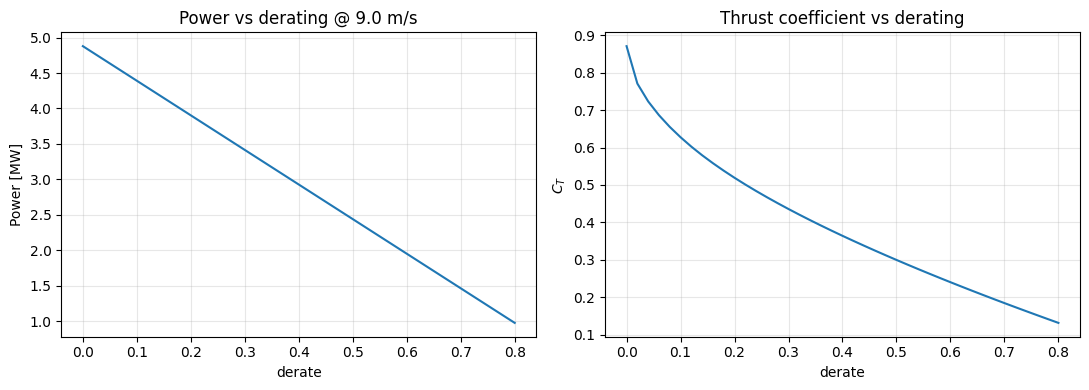

In [4]:
ws_fixed = 9.0
derate = np.linspace(0, 0.8, 41)
ws_arr = np.full_like(derate, ws_fixed)

P = wt.power(ws_arr, derate=derate) / 1e6
Ct = wt.ct(ws_arr, derate=derate)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(derate, P)
axes[0].set_ylabel("Power [MW]")
axes[0].set_title(f"Power vs derating @ {ws_fixed} m/s")
axes[1].plot(derate, Ct)
axes[1].set_ylabel("$C_T$")
axes[1].set_title("Thrust coefficient vs derating")
for ax in axes:
    ax.set_xlabel("derate"); ax.grid(alpha=0.3)
plt.tight_layout()
print("P/P0:", np.round(P / P[0], 3)[::10])
print("Ct  :", np.round(Ct, 3)[::10])

## 4. Yaw x derating interaction

The surrogate's yaw dimension replaces the cos³ `SimpleYawModel`. Its yaw
losses are much milder (the controller re-optimises pitch/TSR under
misalignment), and derating and yaw interact consistently. Note this changes
the *baseline* (derate = 0) yaw behaviour compared to the stock `DTU10MW()`
turbine.

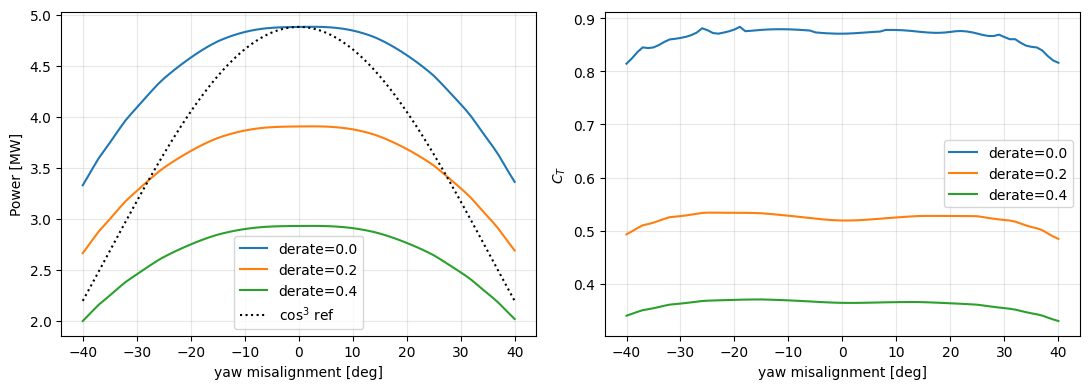

In [5]:
yaw = np.linspace(-40, 40, 81)
ws_arr = np.full_like(yaw, ws_fixed)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for d in [0.0, 0.2, 0.4]:
    P = wt.power(ws_arr, yaw=yaw, derate=np.full_like(yaw, d))
    Ct = wt.ct(ws_arr, yaw=yaw, derate=np.full_like(yaw, d))
    axes[0].plot(yaw, P / 1e6, label=f"derate={d:.1f}")
    axes[1].plot(yaw, Ct, label=f"derate={d:.1f}")

P0 = wt.power(np.array([ws_fixed]))[0]
axes[0].plot(yaw, P0 / 1e6 * np.cos(np.deg2rad(yaw)) ** 3, "k:", label="cos$^3$ ref")
axes[0].set_ylabel("Power [MW]"); axes[1].set_ylabel("$C_T$")
for ax in axes:
    ax.set_xlabel("yaw misalignment [deg]"); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()

## 5. Three side-by-side turbines

Three DTU10MWs, 5D apart in the cross-wind direction so they do not interact.
Wind from the west (270°). Derate levels: T0 = 0%, T1 = 40%, T2 = 80%.

power [MW]: [4.879 2.928 0.976]  ct: [0.871 0.364 0.131]


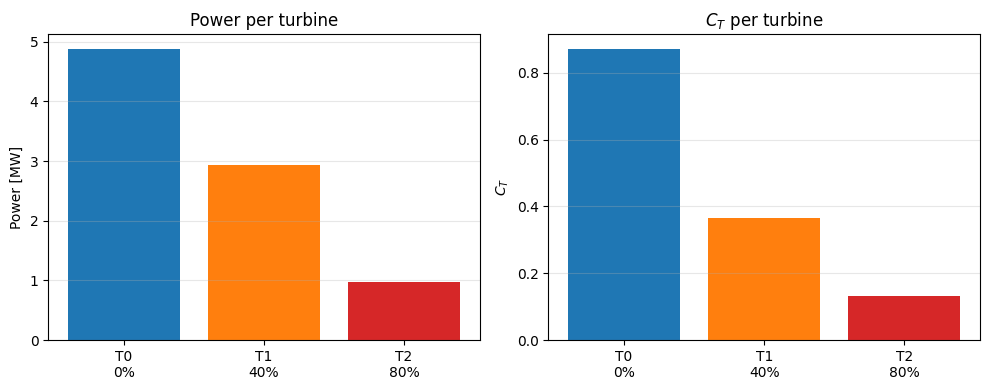

In [6]:
D = wt.diameter()
WS, WD, TI = 9.0, 270.0, 0.06

x_pos = np.array([0.0, 0.0, 0.0])
y_pos = np.array([0.0, 5 * D, 10 * D])
derate_levels = np.array([0.0, 0.4, 0.8])

site = UniformSite(p_wd=[1.0], ti=TI)
model = Blondel_Cathelain_2020(
    site=site, windTurbines=wt,
    turbulenceModel=STF2017TurbulenceModel(),
    deflectionModel=JimenezWakeDeflection(),
)

sim = model(x_pos, y_pos, wd=[WD], ws=[WS], TI=TI, tilt=0,
            yaw=np.zeros(3), derate=derate_levels)

power = sim.Power.values.squeeze() / 1e6
ct = sim.CT.values.squeeze()

colors = ["C0", "C1", "C3"]
labels = [f"T{i}\n{d:.0%}" for i, d in enumerate(derate_levels)]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(range(3), power, color=colors)
axes[0].set_ylabel("Power [MW]"); axes[0].set_title("Power per turbine")
axes[1].bar(range(3), ct, color=colors)
axes[1].set_ylabel("$C_T$"); axes[1].set_title("$C_T$ per turbine")
for ax in axes:
    ax.set_xticks(range(3)); ax.set_xticklabels(labels); ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
print("power [MW]:", power.round(3), " ct:", ct.round(3))

## 6. Flow map — wakes shrink with derating

Each wake deficit scales with the turbine's ct, so higher derating means a
visibly weaker wake.

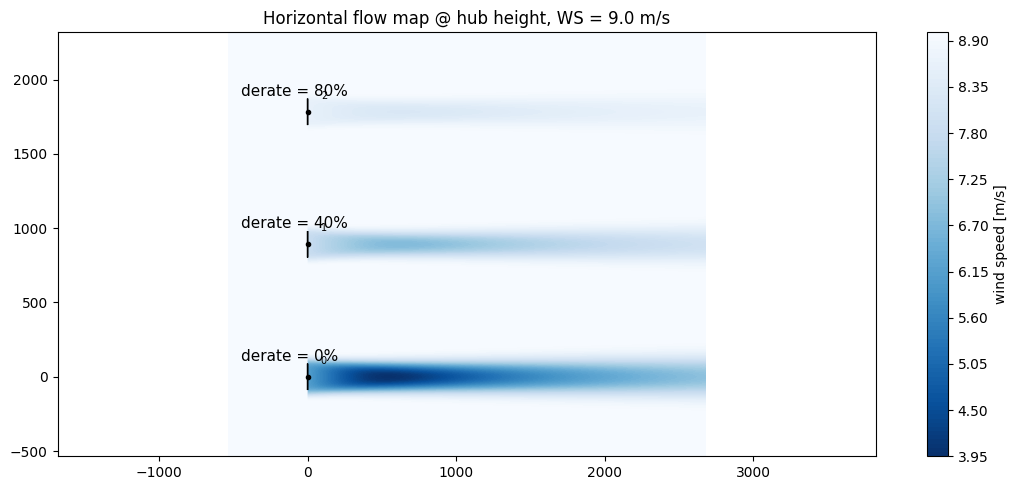

In [7]:
x_grid = np.linspace(-3 * D, 15 * D, 300)
y_grid = np.linspace(-3 * D, 13 * D, 300)

fm = sim.flow_map(grid=HorizontalGrid(x=x_grid, y=y_grid, h=wt.hub_height()))

plt.figure(figsize=(11, 5))
fm.plot_wake_map()
for yi, d in zip(y_pos, derate_levels):
    plt.text(-2.5 * D, yi + 0.6 * D, f"derate = {d:.0%}", fontsize=11)
plt.title(f"Horizontal flow map @ hub height, WS = {WS} m/s")
plt.tight_layout()

## 7. Waked row — the control tradeoff

Now put the three turbines **in a row** (5D streamwise spacing, fully waked)
and sweep the derating of the upstream turbine T0. Its own power drops, but
the weaker wake lets T1 (and T2) recover — the farm total is the balance an
RL agent has to optimise. At 5D / 9 m/s the tradeoff is nearly flat, which is
exactly what makes it an interesting control problem.

farm-optimal T0 derate: 0.25  (farm 5.941 -> 5.991 MW)


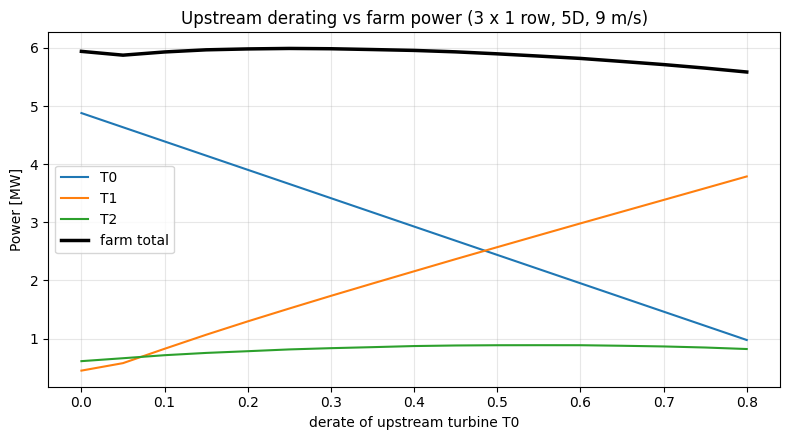

In [8]:
x_row = np.array([0.0, 5 * D, 10 * D])
y_row = np.zeros(3)

d0_sweep = np.linspace(0, 0.8, 17)
P = np.zeros((len(d0_sweep), 3))
for k, d0 in enumerate(d0_sweep):
    s = model(x_row, y_row, wd=[WD], ws=[WS], TI=TI, tilt=0,
              yaw=np.zeros(3), derate=np.array([d0, 0.0, 0.0]))
    P[k] = s.Power.values.squeeze() / 1e6

plt.figure(figsize=(8, 4.5))
for i in range(3):
    plt.plot(d0_sweep, P[:, i], label=f"T{i}")
plt.plot(d0_sweep, P.sum(1), "k-", lw=2.5, label="farm total")
plt.xlabel("derate of upstream turbine T0")
plt.ylabel("Power [MW]")
plt.title("Upstream derating vs farm power (3 x 1 row, 5D, 9 m/s)")
plt.grid(alpha=0.3); plt.legend()
plt.tight_layout()

best = d0_sweep[P.sum(1).argmax()]
print(f"farm-optimal T0 derate: {best:.2f}  "
      f"(farm {P.sum(1)[0]:.3f} -> {P.sum(1).max():.3f} MW)")

## 8. Derating inside WindGym (RL setting)

Enable with `derate_action: true` in the env config. The env only *forwards*
per-turbine derate values — the turbine must accept a `'derate'` input, which
the surrogate turbine does natively.

**Action layout** (values in [-1, 1]):

- `yaw_action: true` (default): `[yaw_0..yaw_n | derate_0..derate_n]`
- `yaw_action: false`: `[derate_0..derate_n]` — derate-only control

**How the derate action is applied** (`derate_method`):

- `"absolute"` (default): the value is the setpoint, affine-mapped to
  `[derate_min, derate_max]`
- `"step"`: the value is a delta of at most `derate_step_env` per env step

**Observation**: each turbine's current derate is added to its measurements
(scaled from [0, 1]), configurable via `derate_mes` and on by default whenever
`derate_action` is set.

In `WindFarmEnvMulti` each agent outputs `[yaw, derate]` (or `[derate]`).

In [9]:
from WindGym import WindFarmEnv

env_config = {
    'derate_action': True,
    'derate_min': 0.0,
    'derate_max': 0.8,          # surrogate table limit
    'derate_method': 'absolute',
    'ActionMethod': 'yaw',
    'yaw_init': 'Zero',
    'farm': {'yaw_min': -30, 'yaw_max': 30},
    'wind': {'ws_min': 9., 'ws_max': 9., 'TI_min': 0.06, 'TI_max': 0.06,
             'wd_min': 270., 'wd_max': 270.},
    'act_pen': {'action_penalty': 0.0, 'action_penalty_type': 'change'},
    'power_def': {'Power_reward': 'Power_avg', 'Power_avg': 5, 'Power_scaling': 1.0},
    'mes_level': {'turb_ws': True, 'turb_wd': False, 'turb_TI': False, 'turb_power': False,
                  'farm_ws': False, 'farm_wd': False, 'farm_TI': False, 'farm_power': False},
    'ws_mes':    {'ws_current': True, 'ws_rolling_mean': False, 'ws_history_N': 1,
                  'ws_history_length': 10, 'ws_window_length': 10},
    'wd_mes':    {'wd_current': True, 'wd_rolling_mean': False, 'wd_history_N': 1,
                  'wd_history_length': 10, 'wd_window_length': 10},
    'yaw_mes':   {'yaw_current': True, 'yaw_rolling_mean': False, 'yaw_history_N': 1,
                  'yaw_history_length': 10, 'yaw_window_length': 10},
    'power_mes': {'power_current': False, 'power_rolling_mean': False, 'power_history_N': 1,
                  'power_history_length': 10, 'power_window_length': 10},
}

env = WindFarmEnv(
    turbine=wt, x_pos=x_row, y_pos=y_row,
    backend="dynamiks", turbtype="Random",
    config=env_config, dt_sim=10, dt_env=10, n_passthrough=10,
)
obs, info = env.reset(seed=0)
print("action space:", env.action_space.shape, " (3 yaw + 3 derate)")
print("obs space:", env.observation_space.shape, " (includes per-turbine derate)")

# derate T0 to 40% (raw 0.0 -> midpoint of [0, 0.8]), keep yaw at 0
action = np.array([0, 0, 0,  0.0, -1.0, -1.0], dtype=np.float32)
obs, reward, term, trunc, info = env.step(action)
print("applied derate:", info["derate agent"])
print("observed derate:", info["derate measured"])
print("per-turbine power [MW]:", (env.fs.windTurbines.power() / 1e6).round(3))
env.close()

# derate-only mode: one action per turbine
env_do = WindFarmEnv(turbine=wt, x_pos=x_row, y_pos=y_row,
                     backend="dynamiks", turbtype="Random",
                     config={**env_config, 'yaw_action': False},
                     dt_sim=10, dt_env=10, n_passthrough=10)
env_do.reset(seed=0)
print("derate-only action space:", env_do.action_space.shape)
env_do.close()

action space: (6,)  (3 yaw + 3 derate)
obs space: (9,)  (includes per-turbine derate)
applied derate: [0.40000001 0.         0.        ]
observed derate: [0.4 0.  0. ]
per-turbine power [MW]: [3.077 0.651 0.   ]


derate-only action space: (3,)


## 9. Rendered flow — the two front turbines derated (gif)

The two front turbines are derated at different levels (T0 = 60%, T1 = 30%,
T2 = 0%). Each env step is rendered into a frame and written to a gif, so you
can watch the weakened wakes advect downstream. The power time series shows
the response: T0 drops instantly, T1/T2 first lose power to their own
derating/wakes, then partially recover as the weaker upstream wakes arrive
(~100 s per 5D at 9 m/s).

saved images/derating_two_front.gif  (6.2 MB, 60 frames)


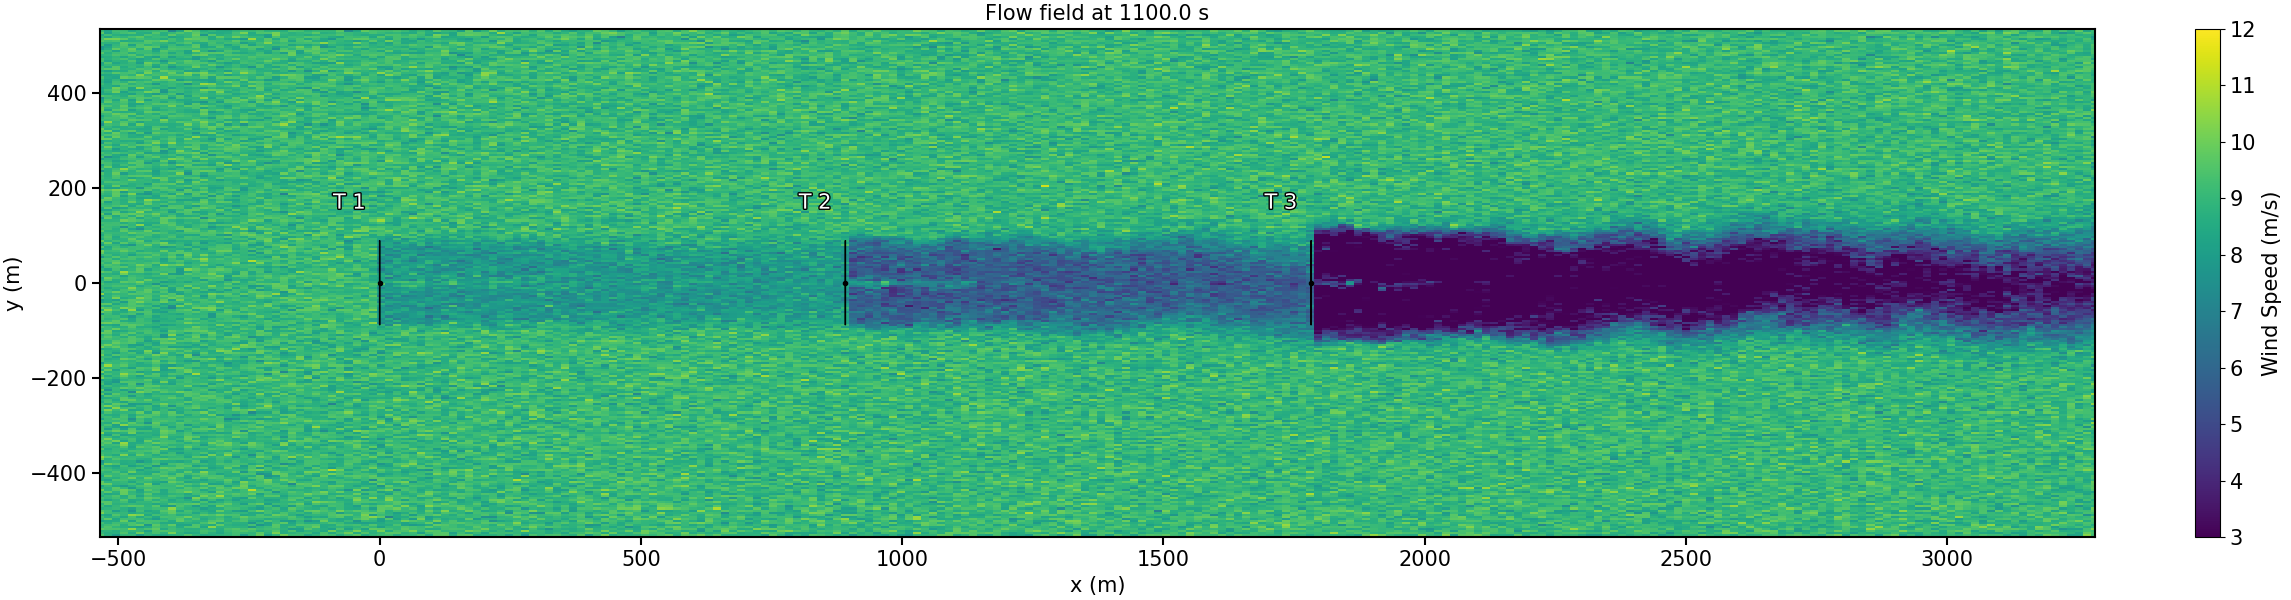

In [10]:
import os
import imageio.v3 as iio
from PIL import Image

env = WindFarmEnv(
    turbine=wt, x_pos=x_row, y_pos=y_row, backend="dynamiks",
    config=env_config, turbtype="Random",
    dt_sim=10, dt_env=10, n_passthrough=10, render_mode="rgb_array",
)
env.reset(seed=0)

derate_front = np.array([0.6, 0.3, 0.0])                     # T0, T1, T2
raw = 2 * derate_front / env_config["derate_max"] - 1        # invert the action map
action = np.concatenate([np.zeros(3), raw]).astype(np.float32)

frames, powers, times = [], [], []
N_steps = 60                                                 # 600 s
for _ in range(N_steps):
    obs, reward, term, trunc, info = env.step(action)
    frames.append(env.render())
    powers.append(env.fs.windTurbines.power() / 1e6)
    times.append(env.fs.time)
env.close()

powers = np.array(powers)
times = np.array(times) - times[0]

gif_path = "images/derating_two_front.gif"
iio.imwrite(gif_path, [f[::2, ::2] for f in frames], duration=125, loop=0)
print(f"saved {gif_path}  ({os.path.getsize(gif_path)/1e6:.1f} MB, {len(frames)} frames)")

fig, ax = plt.subplots(figsize=(9, 4))
for i in range(3):
    ax.plot(times, powers[:, i], label=f"T{i} (derate={derate_front[i]:.0%})")
ax.plot(times, powers.sum(1), "k-", lw=2, label="farm")
ax.set_xlabel("time [s]"); ax.set_ylabel("Power [MW]")
ax.set_title("Per-turbine power while the two front turbines are derated")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.savefig("images/derating_two_front_power.png", dpi=120)

Image.fromarray(frames[-1])   # last rendered frame

## 10. 3 x 1 farm — phase-offset pulsating derating (gif)

Every turbine pulses its derate between 0% and 60% (period 240 s) with a
phase offset of one third of a period (80 s) between consecutive rows — a
"traveling wave" of derating moving downstream. The offset is of the same
order as the wake travel time between rows (~110 s at 9 m/s), so the
low-thrust "puffs" released by one turbine arrive at the next roughly when it
ramps back up. Each turbine's power mixes its own derate pulse with the
delayed wake pulses from upstream; T2's own derating is included for the
visual symmetry even though a real controller would leave the last row at
full power.

saved images/derating_pulsating_3x1.gif  (9.9 MB, 96 frames)


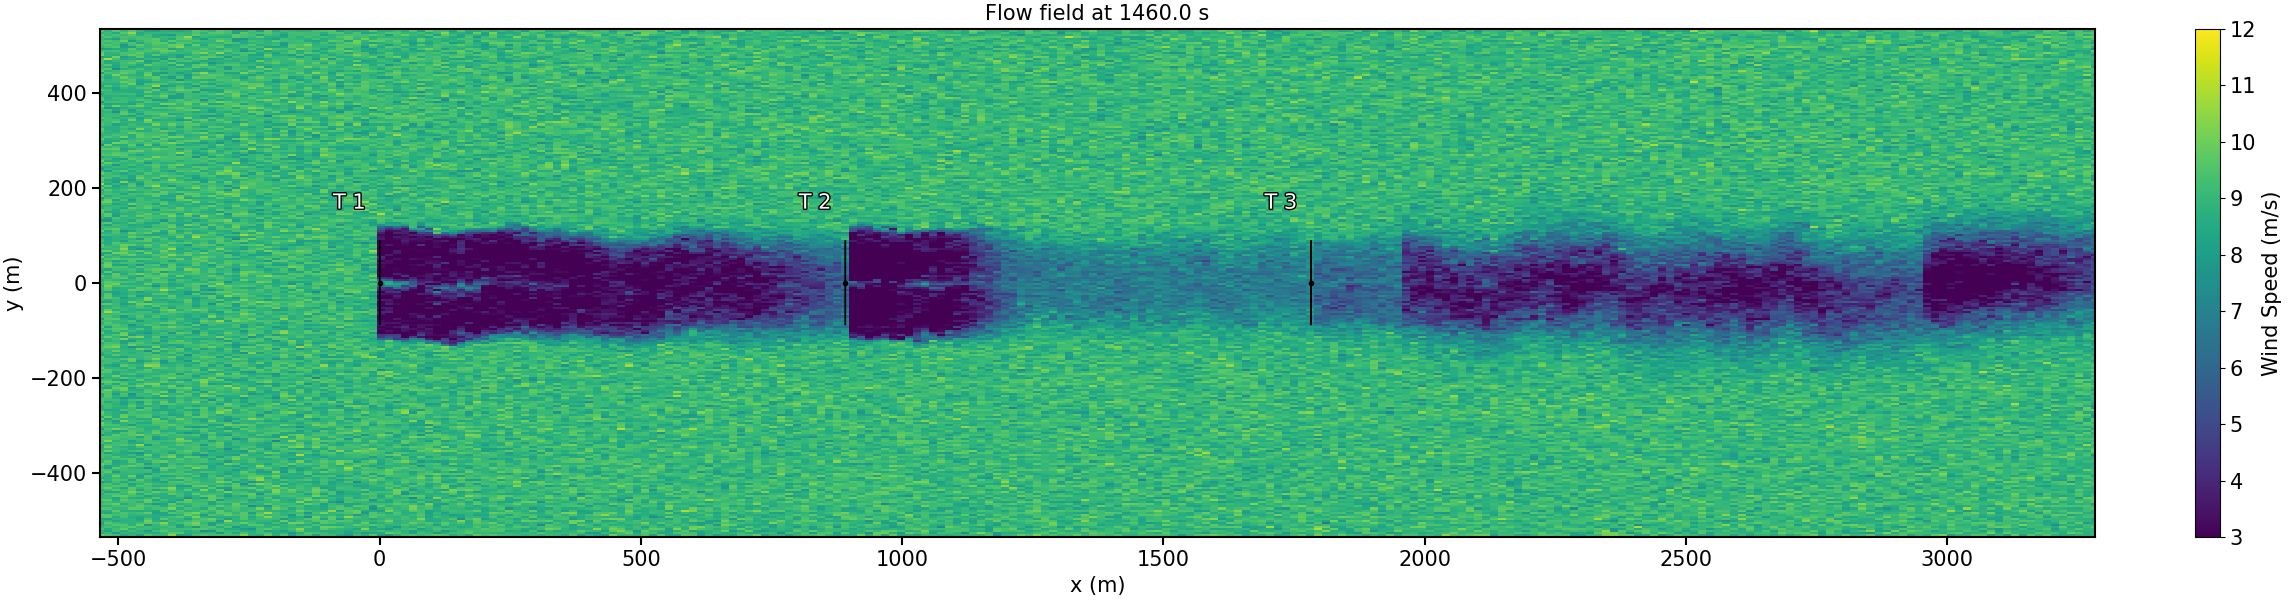

In [11]:
period_s = 240.0
offset_s = period_s / 3      # phase shift between consecutive turbines
d_high = 0.6
N_steps = 96                 # 960 s ≈ 4 pulse cycles

env = WindFarmEnv(
    turbine=wt, x_pos=x_row, y_pos=y_row, backend="dynamiks",
    config=env_config, turbtype="Random",
    dt_sim=10, dt_env=10, n_passthrough=10, render_mode="rgb_array",
)
env.reset(seed=0)

def pulse(t, phase):
    return d_high if ((t - phase) % period_s) < period_s / 2 else 0.0

frames, powers, times, d_trace = [], [], [], []
for k in range(N_steps):
    t = k * env.dt_env
    d = np.array([pulse(t, i * offset_s) for i in range(3)])
    raw = 2 * d / env_config["derate_max"] - 1
    action = np.concatenate([np.zeros(3), raw]).astype(np.float32)
    obs, reward, term, trunc, info = env.step(action)
    frames.append(env.render())
    powers.append(env.fs.windTurbines.power() / 1e6)
    times.append(env.fs.time)
    d_trace.append(d)
env.close()

powers = np.array(powers)
d_trace = np.array(d_trace)
times = np.array(times) - times[0]

gif_path = "images/derating_pulsating_3x1.gif"
iio.imwrite(gif_path, [f[::2, ::2] for f in frames], duration=100, loop=0)
print(f"saved {gif_path}  ({os.path.getsize(gif_path)/1e6:.1f} MB, {len(frames)} frames)")

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})
for i in range(3):
    axes[0].plot(times, powers[:, i], label=f"T{i}")
axes[0].plot(times, powers.sum(1), "k-", lw=2, label="farm")
axes[0].set_ylabel("Power [MW]"); axes[0].grid(alpha=0.3)
axes[0].legend(loc="upper right")
axes[0].set_title("Phase-offset pulsating derating — 3 x 1 row")
for i in range(3):
    axes[1].step(times, d_trace[:, i], where="post", label=f"T{i}")
axes[1].set_ylabel("derate [-]"); axes[1].set_xlabel("time [s]")
axes[1].set_ylim(-0.05, 0.85); axes[1].grid(alpha=0.3)
axes[1].legend(loc="upper right")
plt.tight_layout()
plt.savefig("images/derating_pulsating_3x1_power.png", dpi=120)

Image.fromarray(frames[-1])   # last rendered frame